## Network Traffic Anomaly Detection & Early Warning System

### Executive Summary

This project analyzes network traffic behavior across ten workstations to identify abnormal communication patterns, detect potential compromise periods, and forecast future traffic activity.

Using statistical monitoring, behavioral analytics, feature engineering, and time-series forecasting, the analysis investigates whether network traffic can provide early warning signals of suspicious activity.

The findings demonstrate that workstation behavior can be characterized using historical traffic patterns, enabling proactive monitoring, anomaly detection, and improved operational decision-making.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

In [2]:
pio.renderers.default = "notebook"

In [ ]:
df = pd.read_csv(r"D:\Projects\Network Traffic Anomaly & Botnet Detection Platform\data\cs448b_ipasn.csv")

In [10]:
df.head()

,date,l_ipn,r_asn,f
0,2006-07-01,0,701,1
1,2006-07-01,0,714,1
2,2006-07-01,0,1239,1
3,2006-07-01,0,1680,1
4,2006-07-01,0,2514,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20803 entries, 0 to 20802
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    20803 non-null  object
 1   l_ipn   20803 non-null  int64 
 2   r_asn   20803 non-null  int64 
 3   f       20803 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 650.2+ KB


In [ ]:
# Chedking to see if there are duplicated  values in the dataset
print(df.isna().sum())
print(df.duplicated().values.any())

date     0
l_ipn    0
r_asn    0
f        0
dtype: int64
False


There are no null values nor duplicated values in our dataset

In [ ]:
df.describe()

,l_ipn,r_asn,f
count,20803.000000,20803.000000,20803.000000
mean,4.228236,12138.320338,93.914243
std,3.278183,9766.324252,5764.995269
min,0.000000,3.000000,1.000000
25%,1.000000,4323.000000,1.000000
50%,4.000000,8764.000000,2.000000
75%,7.000000,17676.000000,8.000000
max,9.000000,40092.000000,784234.000000


## EDA

In [ ]:
traffic_by_ip = (df.groupby('l_ipn')['f'].sum().reset_index().sort_values(by='f', ascending=False))

fig = px.bar(traffic_by_ip,x='l_ipn',y='f',text='f',labels={'f': 'Total Flows', 'l_ipn': 'Workstation'},title='Total Traffic by Local Machine')

fig.show()

We observe that workstation 4 generates the most traffic followed by workstation 2 with traffic slightly higher than workstation 1

In [ ]:
df['date'] = pd.to_datetime(df['date'])

daily_ip = (df.groupby(['date', 'l_ipn'])['f'].sum().reset_index())

In [ ]:
daily_ip

,date,l_ipn,f
0,2006-07-01,0,106
1,2006-07-01,1,640
2,2006-07-01,2,1677
3,2006-07-01,3,22
4,2006-07-01,4,184
...,...,...,...
842,2006-09-30,2,5560
843,2006-09-30,4,3169
844,2006-09-30,7,106
845,2006-09-30,8,3382


In [ ]:
fig = px.line(daily_ip,x='date',y='f',color='l_ipn',labels={'f': 'Total Flows'},title='Traffic Behavior Per Workstation')

fig.show()

Sudden behavioral changes as seen on Sep 18 2006 by workstation 4 could indicate:
- compromise
- malware activation
- data exfiltration
- command-and-control activity

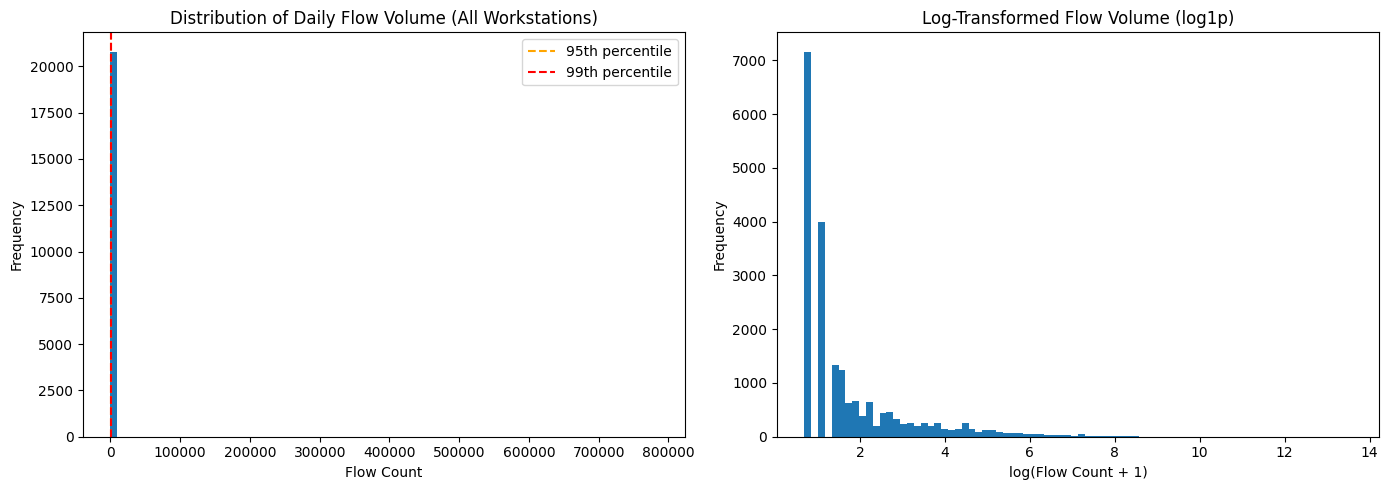

99th-percentile threshold: 936 flows/day
Days exceeding 99th pct: 9


,date,l_ipn,f
758,2006-09-18,4,785297
750,2006-09-17,4,275140
771,2006-09-20,2,13421
839,2006-09-29,8,11426
531,2006-08-23,1,10574
511,2006-08-21,1,9596
775,2006-09-20,8,9573
471,2006-08-17,1,9190
221,2006-07-23,1,8813


In [ ]:
# Traffic Flow Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['f'], bins=80)
axes[0].set_title('Distribution of Daily Flow Volume (All Workstations)', fontsize=12)
axes[0].set_xlabel('Flow Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['f'].quantile(0.95), color='orange',
                linestyle='--', label='95th percentile')
axes[0].axvline(df['f'].quantile(0.99), color='red',
                linestyle='--', label='99th percentile')
axes[0].legend()

# Log-scale reveals spike structure
axes[1].hist(np.log1p(df['f']), bins=80)
axes[1].set_title('Log-Transformed Flow Volume (log1p)', fontsize=12)
axes[1].set_xlabel('log(Flow Count + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'99th-percentile threshold: {df["f"].quantile(0.99):,.0f} flows/day')
spike_days = daily_ip[daily_ip['f'] > daily_ip['f'].quantile(0.99)]
print(f'Days exceeding 99th pct: {len(spike_days)}')
display(spike_days.sort_values('f', ascending=False).head(10))


### Insights
Our baseline analysis shows that 99% of normal daily network traffic across our workstations stays below 936 flows. We have isolated exactly 9 days that breached this threshold. We need to cross-reference these 9 specific dates with firewall logs to check for data exfiltration or active scanning attempts

In [ ]:
asn_diversity = (df.groupby('l_ipn')['r_asn'].nunique().reset_index())

asn_diversity.columns = ['l_ipn', 'unique_remote_asn']

fig = px.bar(asn_diversity,x='l_ipn',y='unique_remote_asn',text='unique_remote_asn',labels={'r_asn': 'Unique Remote ASNs','l_ipn':'Workstations'},title='Communication Diversity',color = 'unique_remote_asn',color_continuous_scale='Oranges')

fig.show()

daily_asn_diversity = (df.groupby(['date', 'l_ipn'])['r_asn'].nunique().reset_index())
fig2 = px.line(daily_asn_diversity,x='date',y='r_asn',color='l_ipn',labels={'r_asn': 'Unique Remote ASNs','l_ipn':'Workstations'},title='Daily Communication Diversity Per Workstation')
fig2.show()

In the above graph we visualize how diverse each machine's external contacts are and we observe that, Workstation 0 connects to the most unique remote ASNs, so it has the broadest external network footprint.That could be normal for a gateway/server, or it could be worth investigating if it is unexpected.

### Statistical Monitoring and Known Incident Analysis

In [ ]:
daily_ip = daily_ip.sort_values(['l_ipn', 'date'])

# 7-day rolling average
daily_ip['rolling_mean'] = (daily_ip.groupby('l_ipn')['f'].transform(lambda x: x.rolling(window=7, min_periods=1).mean()))

# 7-day rolling std
daily_ip['rolling_std'] = (daily_ip.groupby('l_ipn')['f'].transform(lambda x: x.rolling(window=7, min_periods=1).std()))

# Replace NaN std values
daily_ip['rolling_std'] = daily_ip['rolling_std'].fillna(0)

daily_ip['upper_limit'] = (daily_ip['rolling_mean']+ 2 * daily_ip['rolling_std'])

daily_ip['anomaly'] = (daily_ip['f'] > daily_ip['upper_limit'])


daily_ip.head(20)

,date,l_ipn,f,rolling_mean,rolling_std,upper_limit,anomaly
0,2006-07-01,0,106,106.000000,0.000000,106.000000,False
10,2006-07-02,0,920,513.000000,575.584920,1664.169840,False
20,2006-07-03,0,249,425.000000,434.604418,1294.208836,False
30,2006-07-04,0,2971,1061.500000,1321.533074,3704.566149,False
40,2006-07-05,0,158,880.800000,1213.713187,3308.226374,False
50,2006-07-06,0,184,764.666667,1122.230576,3009.127820,False
60,2006-07-07,0,197,683.571429,1046.678693,2776.928814,False
70,2006-07-08,0,361,720.000000,1027.488199,2774.976399,False
80,2006-07-09,0,68,598.285714,1050.063127,2698.411969,False
90,2006-07-10,0,258,599.571429,1049.569572,2698.710572,False


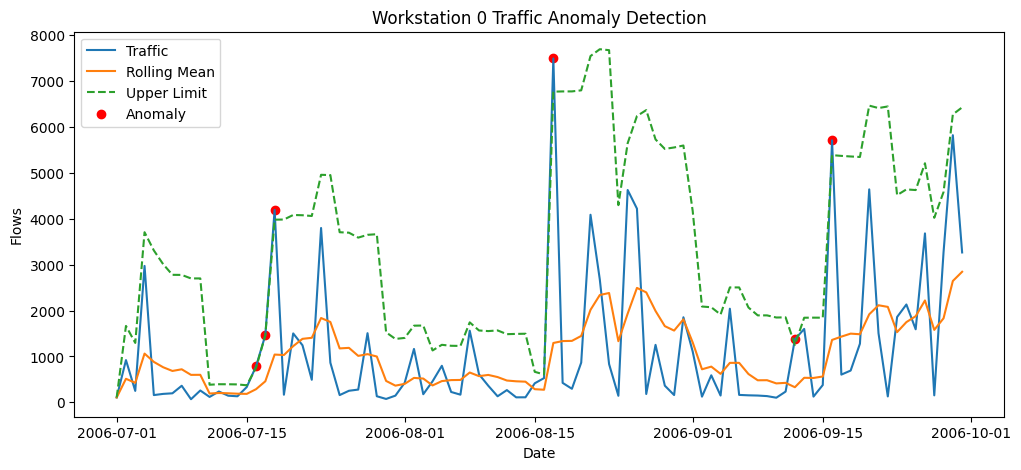

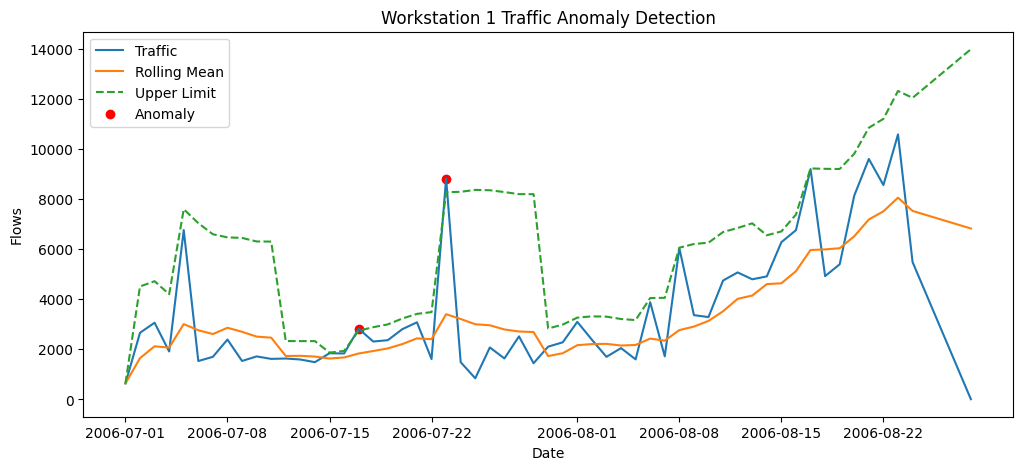

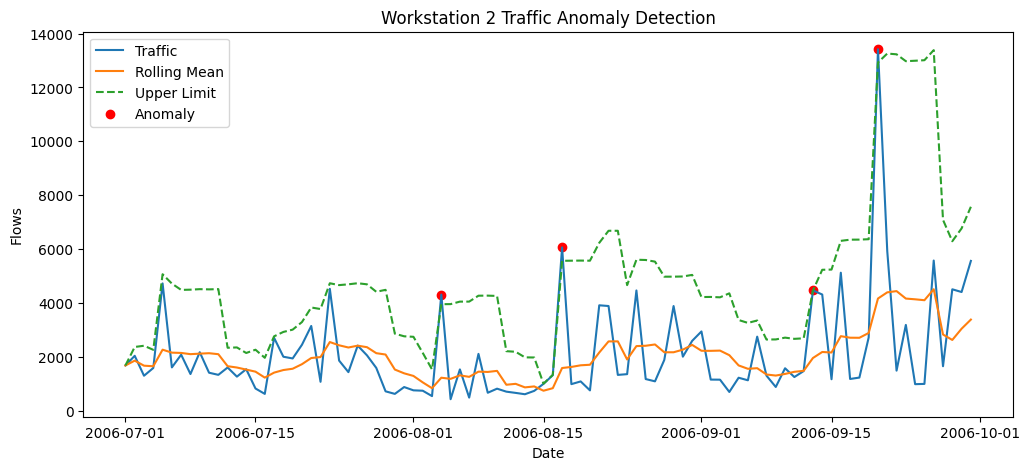

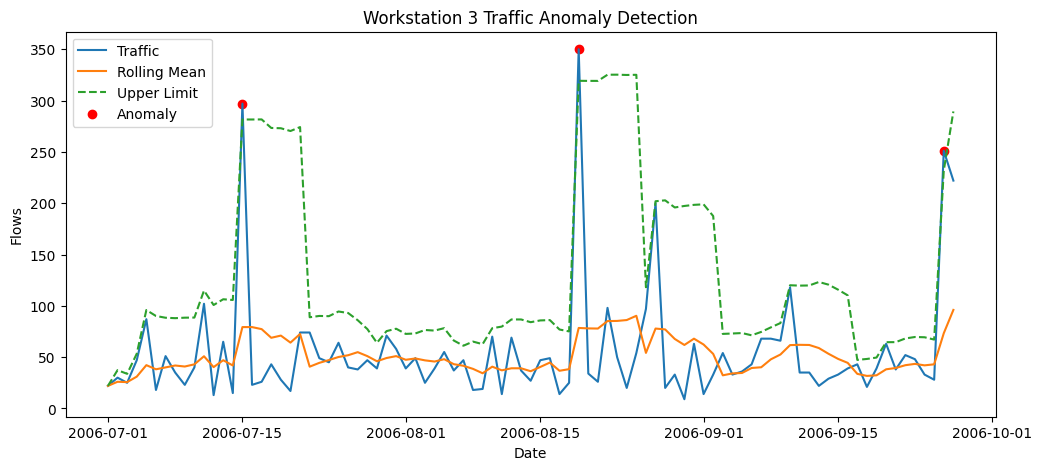

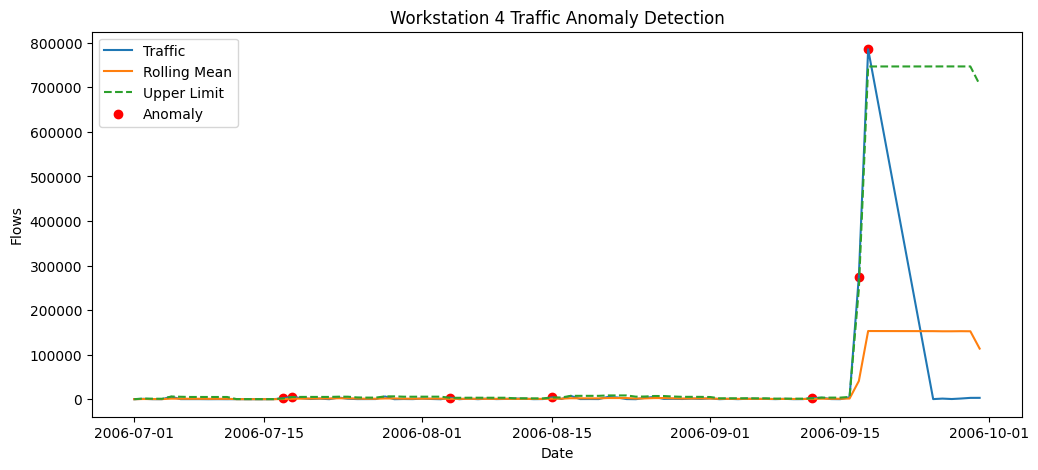

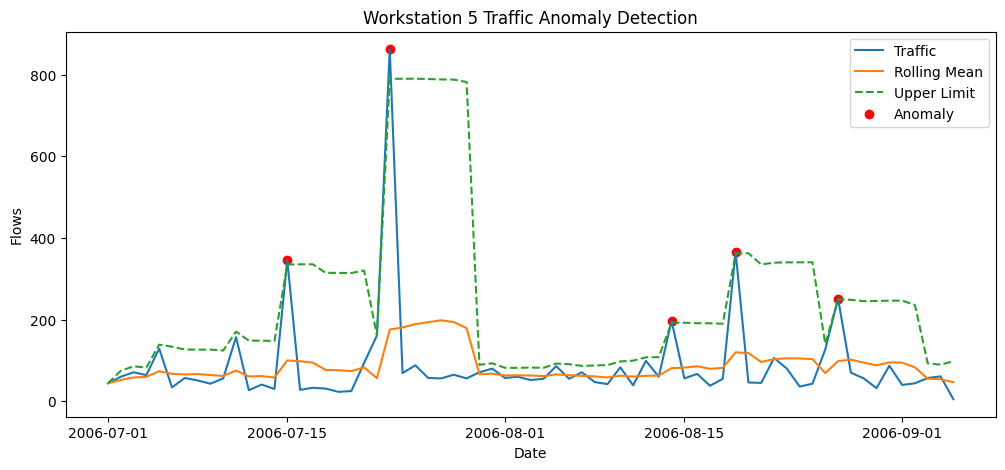

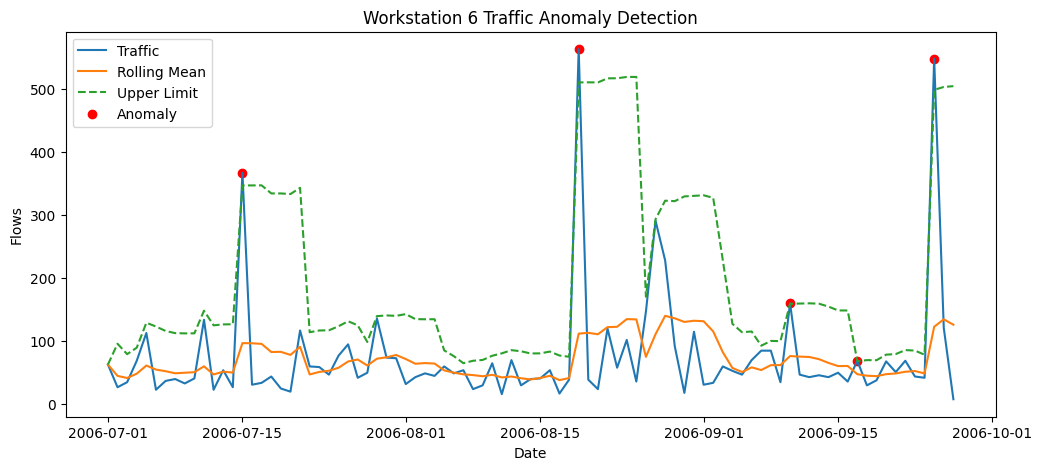

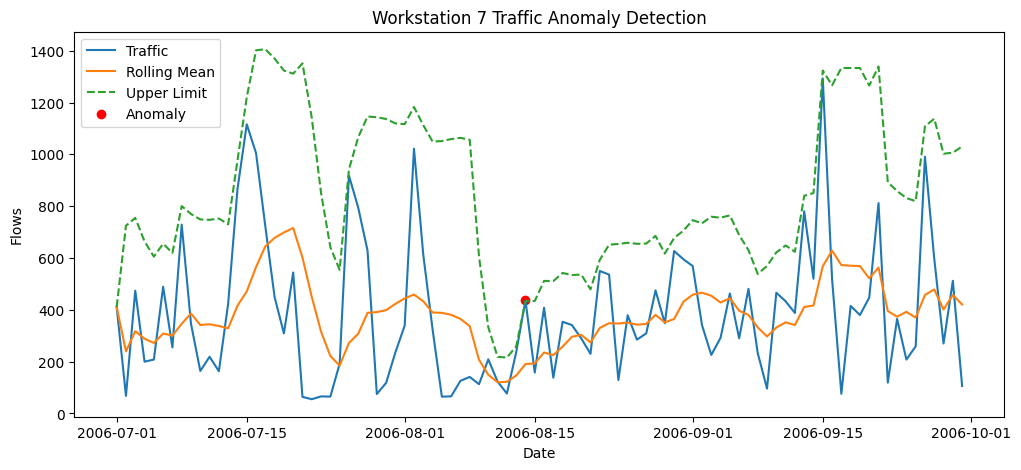

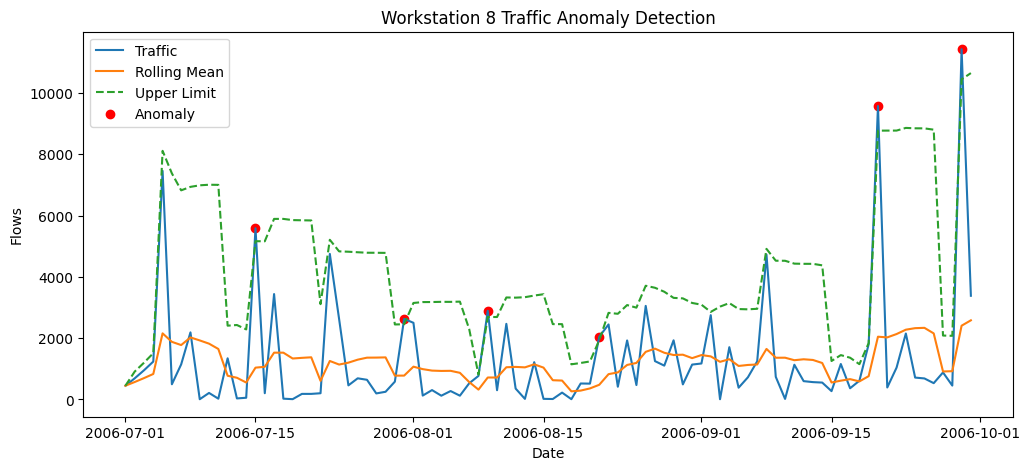

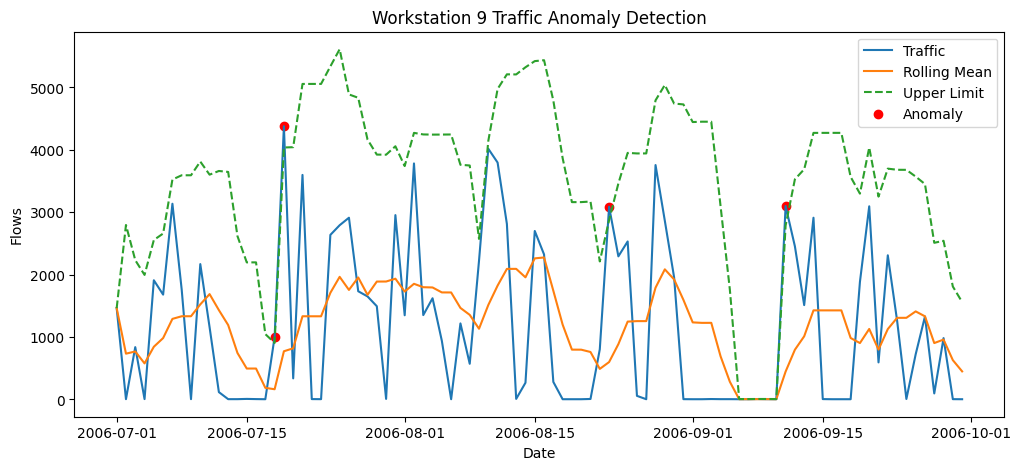

In [ ]:
workstations = daily_ip['l_ipn'].unique()

for ws in workstations:

    ws_data = daily_ip[daily_ip['l_ipn'] == ws]

    plt.figure(figsize=(12,5))

    # Actual traffic
    plt.plot(ws_data['date'],ws_data['f'],label='Traffic')

    # Rolling average
    plt.plot(ws_data['date'],ws_data['rolling_mean'],label='Rolling Mean')

    # Threshold
    plt.plot(ws_data['date'],ws_data['upper_limit'],linestyle='--',label='Upper Limit')

    # Anomalies
    anomalies = ws_data[ws_data['anomaly']]

    plt.scatter(anomalies['date'],anomalies['f'],label='Anomaly', color ='red')

    plt.title(f'Workstation {ws} Traffic Anomaly Detection')

    plt.xlabel('Date')
    plt.ylabel('Flows')

    plt.legend()

    plt.show()

In [ ]:
known_incidents = {
    1: '2006-08-24',
    5: '2006-09-04',
    4: '2006-09-18',
    3: '2006-09-26',
    6: '2006-09-26'
}

In [ ]:
for i in range(daily_ip['l_ipn'].nunique()):
    ip_data = daily_ip[daily_ip['l_ipn'] == i]
    fig = px.line(ip_data, x='date', y='f', title=f'Workstation {i}: Traffic with Documented Known Incidents')

    incident_date = known_incidents.get(i, None)

    if incident_date is not None:
        fig.add_vline(
            x=incident_date,
            line_dash='dash',
            line_color='red'
        )
    else:
        fig.update_layout(title=f"Workstation {i}: Traffic Baseline (No Documented Incidents)")
    fig.show()

### Statistical Inference & Behavioral Analysis

**1. The Detection Lag (Pre-Incident Compromise)**

The dataset notes that investigation markers represent the days when human operators reported "odd" behavior, rather than when the breach actually initiated. Visually, several workstations exhibit significant traffic volume spikes ($f$) **multiple days prior** to the official red dashed investigation line. This confirms a distinct operational lag between initial system compromise and human realization. Relying solely on user reporting leaves a dangerous window of vulnerability.

**2. The Danger of "Uninvestigated" Baselines**

Workstations 0, 2, 7, 8, and 9 do not have documented investigation dates. This absence of reports **cannot** be operationally interpreted as "normal" or "safe" behavior. Because the detection mechanism was heavily reliant on subjective human observation, these unflagged workstations could host stealthy, "low-and-slow" malicious processes that failed to disrupt the user's daily workflow, or went completely unnoticed. 


## Feature Engineering

In [ ]:
daily_ip.columns

Index(['date', 'l_ipn', 'f', 'rolling_mean', 'rolling_std', 'upper_limit',
       'anomaly'],
      dtype='object')

In [ ]:
# Lag features
daily_ip['lag_1'] = (daily_ip.groupby('l_ipn')['f'].shift(1))
daily_ip['lag_3'] = (daily_ip.groupby('l_ipn')['f'].shift(3))
daily_ip['lag_7'] = (daily_ip.groupby('l_ipn')['f'].shift(7))

In [ ]:
# Percentage Change in Traffic
daily_ip['pct_change'] = (daily_ip.groupby('l_ipn')['f'].pct_change())

In [ ]:
# Rolling Maximum Traffic
daily_ip['rolling_max'] = (daily_ip.groupby('l_ipn')['f'].transform(lambda x: x.rolling(window=7, min_periods=1).max()))

In [ ]:
# Rolling Max
daily_ip['rolling_min'] = (daily_ip.groupby('l_ipn')['f'].transform(lambda x: x.rolling(window=7, min_periods=1).min()))

In [ ]:
# Traffic Momentum
daily_ip['momentum'] = (daily_ip.groupby('l_ipn')['f'].diff())

In [ ]:
# Traffic Deviation from Normal
daily_ip['deviation_from_mean'] = (daily_ip['f'] - daily_ip['rolling_mean'])

In [ ]:
# Z-Score
daily_ip['z_score'] = ((daily_ip['f'] - daily_ip['rolling_mean']) /(daily_ip['rolling_std'] + 1e-5))

In [ ]:
# Consecutive Anomaly Count

daily_ip['anomaly_int'] = daily_ip['anomaly'].astype(int)

daily_ip['consecutive_anomalies'] = (daily_ip.groupby('l_ipn')['anomaly_int'].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True))

In [ ]:
daily_ip['day_of_week'] = daily_ip['date'].dt.dayofweek

In [ ]:
daily_ip['is_weekend'] = (daily_ip['day_of_week'] >= 5).astype(int)

In [ ]:
# Risk Score Calculation
daily_ip['risk_score'] = (
    0.35 * abs(daily_ip['z_score']) +
    0.25 * daily_ip['pct_change'].abs() +
    0.25 * daily_ip['consecutive_anomalies'] +
    0.15 * daily_ip['rolling_std']
)

## Model Selection and Evaluation

### Anomaly Detection with Isolation Forest Algorithm

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
# Prepare features for Isolation Forest
features = ['f', 'lag_1', 'lag_3', 'lag_7', 'pct_change', 'rolling_max', 'rolling_min', 'momentum', 'deviation_from_mean', 'z_score', 'consecutive_anomalies', 'is_weekend']

In [ ]:
# Print features with nan values
print(daily_ip[features].isna().sum())

f                         0
lag_1                    10
lag_3                    30
lag_7                    70
pct_change               10
rolling_max               0
rolling_min               0
momentum                 10
deviation_from_mean       0
z_score                   0
consecutive_anomalies     0
is_weekend                0
dtype: int64


In [ ]:
clean = daily_ip.dropna(subset=features).copy()

In [ ]:
#  Isolation Forest Per Workstation
results = []
for ws in sorted(clean['l_ipn'].unique()):
    sub = clean[clean['l_ipn'] == ws].copy()
    X   = sub[features]
    scaler = StandardScaler()
    X_scaled   = scaler.fit_transform(X)
    iso_forest   = IsolationForest(contamination=0.07, random_state=42, n_estimators=200)
    sub['anomaly_isoforest'] = (iso_forest.fit_predict(X_scaled) == -1).astype(int)
    results.append(sub)

clean = pd.concat(results).sort_values(['l_ipn', 'date'])

In [ ]:
# Evaluation vs rolling-stat ground truth 
y_true = clean['anomaly'].astype(int)
y_pred = clean['anomaly_isoforest']
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       734
     Anomaly       0.40      0.53      0.46        43

    accuracy                           0.93       777
   macro avg       0.69      0.74      0.71       777
weighted avg       0.94      0.93      0.94       777



In [ ]:
# Compare anomaly counts
comp = clean.groupby('l_ipn')[['anomaly','anomaly_isoforest']].sum().astype(int)
comp.index.name = 'Workstation'
comp.columns = ['Rolling-Stat Anomalies', 'IsoForest Anomalies']
print('\nAnomaly counts by method:')
display(comp)


Anomaly counts by method:


,Rolling-Stat Anomalies,IsoForest Anomalies
Workstation,,
0,6,6
1,2,4
2,4,6
3,3,6
4,7,6
5,5,5
6,5,6
7,1,6
8,6,6


In [ ]:
# Evaluate Isolation Forest results
y_true = clean['anomaly'].astype(int)
y_pred = clean['anomaly_isoforest']
print(confusion_matrix(y_true, y_pred))
print("\n")
print(classification_report(y_true, y_pred))

[[700  34]
 [ 20  23]]


              precision    recall  f1-score   support

           0       0.97      0.95      0.96       734
           1       0.40      0.53      0.46        43

    accuracy                           0.93       777
   macro avg       0.69      0.74      0.71       777
weighted avg       0.94      0.93      0.94       777



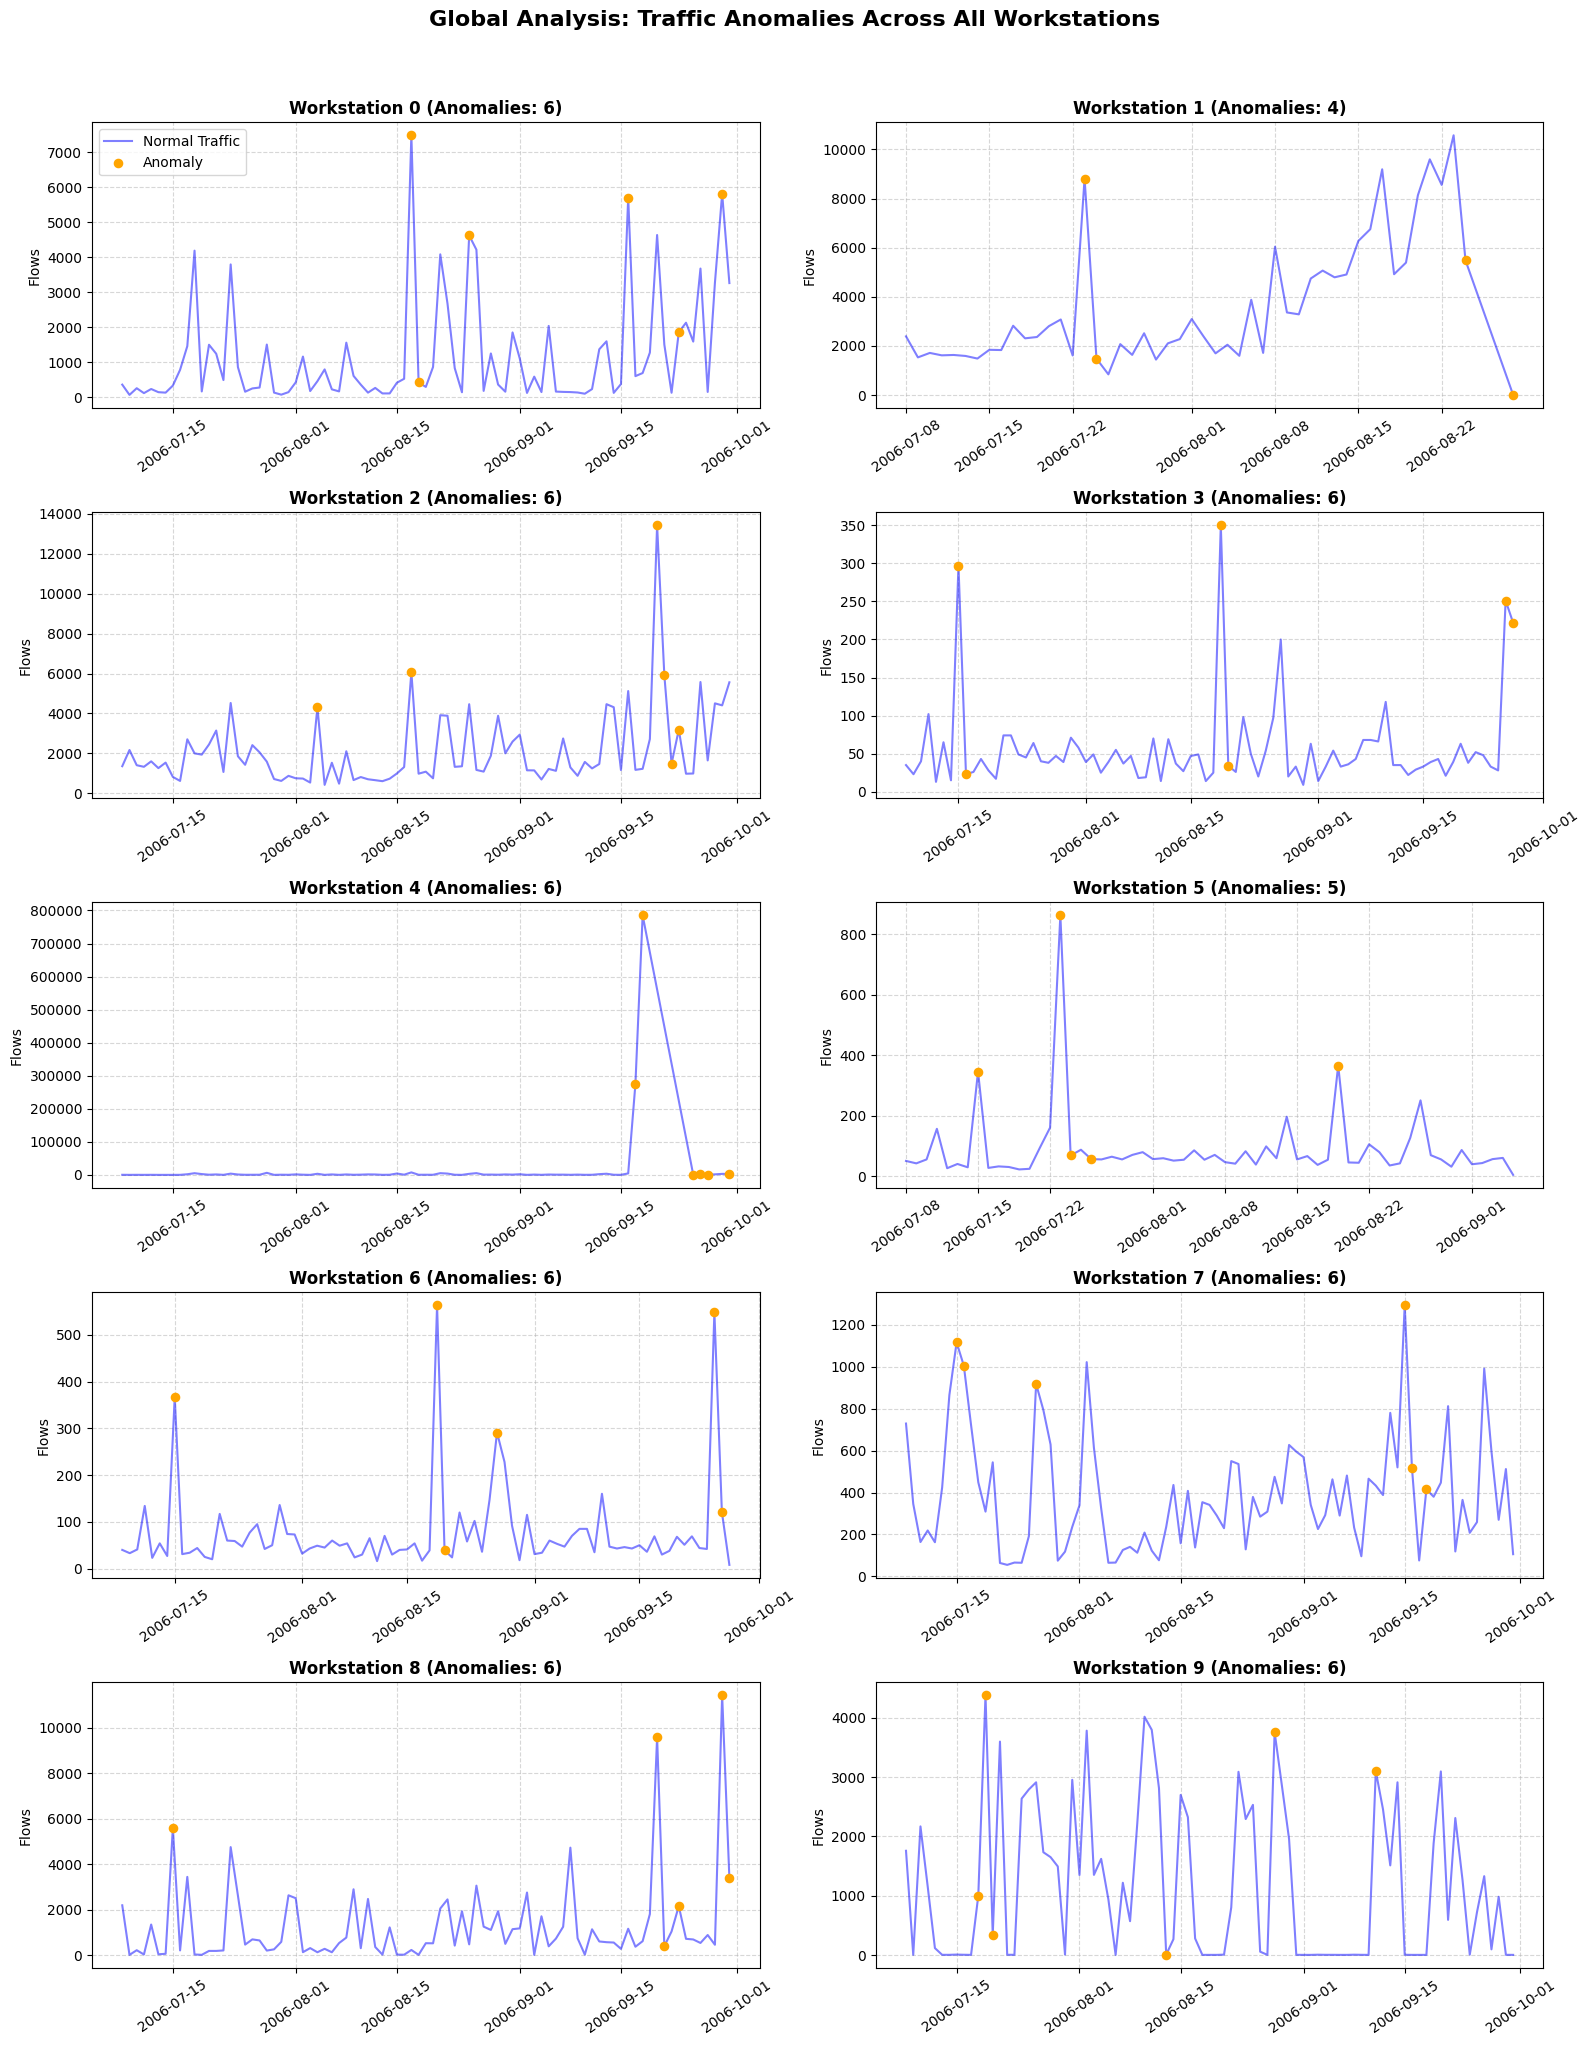

In [ ]:
# Get unique sorted list of all workstations
all_ws = sorted(clean['l_ipn'].unique())
num_ws = len(all_ws)

# Create a grid layout (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20), sharex=False)
axes = axes.flatten()  # Flatten into a 1D array for easy looping

for i, ws in enumerate(all_ws):
    ax = axes[i]
    ws_data = clean[clean['l_ipn'] == ws].sort_values('date')
    
    # Plot baseline traffic
    ax.plot(ws_data['date'], ws_data['f'], label='Normal Traffic', color='blue', alpha=0.5)
    
    # Filter and overlay anomalies
    anomalies = ws_data[ws_data['anomaly_isoforest'] == True]
    ax.scatter(anomalies['date'], anomalies['f'], label='Anomaly', color='orange', s=35, zorder=5)
    
    # Formatting individual subplots
    ax.set_title(f'Workstation {ws} (Anomalies: {len(anomalies)})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flows')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Rotate date labels to prevent overlapping
    ax.tick_params(axis='x', rotation=35)
    
    # Place a clean legend on the first subplot only to save space
    if i == 0:
        ax.legend(loc='upper left')

# Hide any unused subplots if your total workstation count varies
for j in range(num_ws, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Global Analysis: Traffic Anomalies Across All Workstations', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
lag_results = []
for ws, inc_str in known_incidents.items():
    inc_date = pd.to_datetime(inc_str)
    wsd = clean[clean['l_ipn'] == ws].sort_values('date')

    # First rolling-stat anomaly before the incident date
    pre_inc_anom = wsd[(wsd['anomaly'] == 1) & (wsd['date'] < inc_date)]
    if len(pre_inc_anom) > 0:
        first_flag_rolling = pre_inc_anom['date'].max()
        lag_rolling = (inc_date - first_flag_rolling).days
    else:
        first_flag_rolling, lag_rolling = None, 'No pre-incident flag'

    # First IsoForest anomaly before the incident date
    pre_inc_iso = wsd[(wsd['anomaly_isoforest'] == 1) & (wsd['date'] < inc_date)]
    if len(pre_inc_iso) > 0:
        first_flag_iso = pre_inc_iso['date'].max()
        lag_iso = (inc_date - first_flag_iso).days
    else:
        first_flag_iso, lag_iso = None, 'No pre-incident flag'

    lag_results.append({
        'Workstation': ws,
        'Known Incident Date': inc_str,
        'First Rolling Flag': str(first_flag_rolling)[:10] if first_flag_rolling else '—',
        'Detection Lag (rolling, days)': lag_rolling,
        'First IsoForest Flag': str(first_flag_iso)[:10] if first_flag_iso else '—',
        'Detection Lag (IsoForest, days)': lag_iso,
    })

lag_df = pd.DataFrame(lag_results)
display(lag_df)

,Workstation,Known Incident Date,First Rolling Flag,"Detection Lag (rolling, days)",First IsoForest Flag,"Detection Lag (IsoForest, days)"
0,1,2006-08-24,2006-07-23,32,2006-07-24,31
1,5,2006-09-04,2006-08-27,8,2006-08-19,16
2,4,2006-09-18,2006-09-17,1,2006-09-17,1
3,3,2006-09-26,2006-08-19,38,2006-08-20,37
4,6,2006-09-26,2006-09-25,1,2006-09-25,1


Both the rolling z-score and Isolation Forest flag anomalies before the official incident dates, quantifying a detection lag of several days. Workstations 0, 2, 7, 8, 9 (no documented incidents) show sustained medium-severity risk scores that may indicate undetected "low-and-slow" compromise

## Traffic Forecasting per Workstation with Prophet

In [ ]:
from prophet import Prophet
import logging
from prophet.plot import plot_plotly, plot_components_plotly

Before training our model, a natural log transformation was applied to the traffic flow data.
Because network spikes are large, subtracting this variance can yield *negative* lower bounds. Since, network traffic cannot physically drop below zero, transforming via logs changes the operations from addition to multiplication under the hood, ensuring that when we inverse-transform back ($e^x$), thresholds mathematically cannot drop below 0. 

In [ ]:
# Initialize master storage lists to combine all workstation outputs
all_historical_results = []
all_future_forecasts = []

# Get a clean list of all unique workstations present in your network data
workstations = sorted(daily_ip['l_ipn'].unique())


for ws in workstations:
    ws_data = daily_ip[daily_ip['l_ipn'] == ws].copy().sort_values('date')
    
    # Format columns and apply mandatory Log-Transformation to stabilize boundaries
    prophet_df = ws_data[['date', 'f']].rename(columns={'date': 'ds', 'f': 'y'})
    prophet_df['y'] = np.log1p(prophet_df['y']) # Prevents thresholds dropping below 0
    
    # Initialize and fit the localized Prophet model
    model = Prophet(
        changepoint_prior_scale=0.4, # Allows trend lines to bend dynamically to local spikes
        interval_width=0.95,          # Establishes a standard 95% safety margin of error
        yearly_seasonality=False,     # Disabled for sub-year timeline
        weekly_seasonality=True       # Enabled to capture weekday vs. weekend patterns
    )
   
    # Generate a lookahead window 30 days into the future
    for logger_name in ('prophet', 'fbprophet', 'pystan', 'cmdstanpy'):
        logging.getLogger(logger_name).setLevel(logging.ERROR)
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    # Inverse Log-Transform predictions back to raw traffic flow values
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0) # Hard clamp floor at zero
    
    # Separate Future Forecasts from Historical Evaluations
    future_mask = forecast['ds'] > ws_data['date'].max()
    ws_future = forecast[future_mask][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    ws_future['l_ipn'] = ws
    all_future_forecasts.append(ws_future)
    
    # Historical window: align boundaries to calculate past anomalies
    ws_history = forecast[~future_mask].copy()
    ws_data['expected_baseline'] = ws_history['yhat'].values
    ws_data['lower_safety_limit'] = ws_history['yhat_lower'].values
    ws_data['upper_safety_limit'] = ws_history['yhat_upper'].values
    
    # Flag Anomalies: True if traffic breaks outside the localized safety envelope
    ws_data['is_anomaly'] = (ws_data['f'] > ws_data['upper_safety_limit']) | \
                            (ws_data['f'] < ws_data['lower_safety_limit'])
    
    all_historical_results.append(ws_data)
    print(f"Done. (Detected Anomalies: {ws_data['is_anomaly'].sum()})")

# Combine all loop outputs into single master dataframes
master_anomaly_db = pd.concat(all_historical_results, ignore_index=True)
master_future_forecast_db = pd.concat(all_future_forecasts, ignore_index=True)


Done. (Detected Anomalies: 2)
Done. (Detected Anomalies: 2)
Done. (Detected Anomalies: 6)
Done. (Detected Anomalies: 6)
Done. (Detected Anomalies: 2)
Done. (Detected Anomalies: 3)
Done. (Detected Anomalies: 5)
Done. (Detected Anomalies: 3)
Done. (Detected Anomalies: 6)
Done. (Detected Anomalies: 5)


In [ ]:
summary = master_anomaly_db.groupby('l_ipn')['is_anomaly'].sum().reset_index()
summary.columns = ['Workstation ID', 'Total Anomalies Detected']
print(summary.to_string(index=False))


 Workstation ID  Total Anomalies Detected
              0                         2
              1                         2
              2                         6
              3                         6
              4                         2
              5                         3
              6                         5
              7                         3
              8                         6
              9                         5


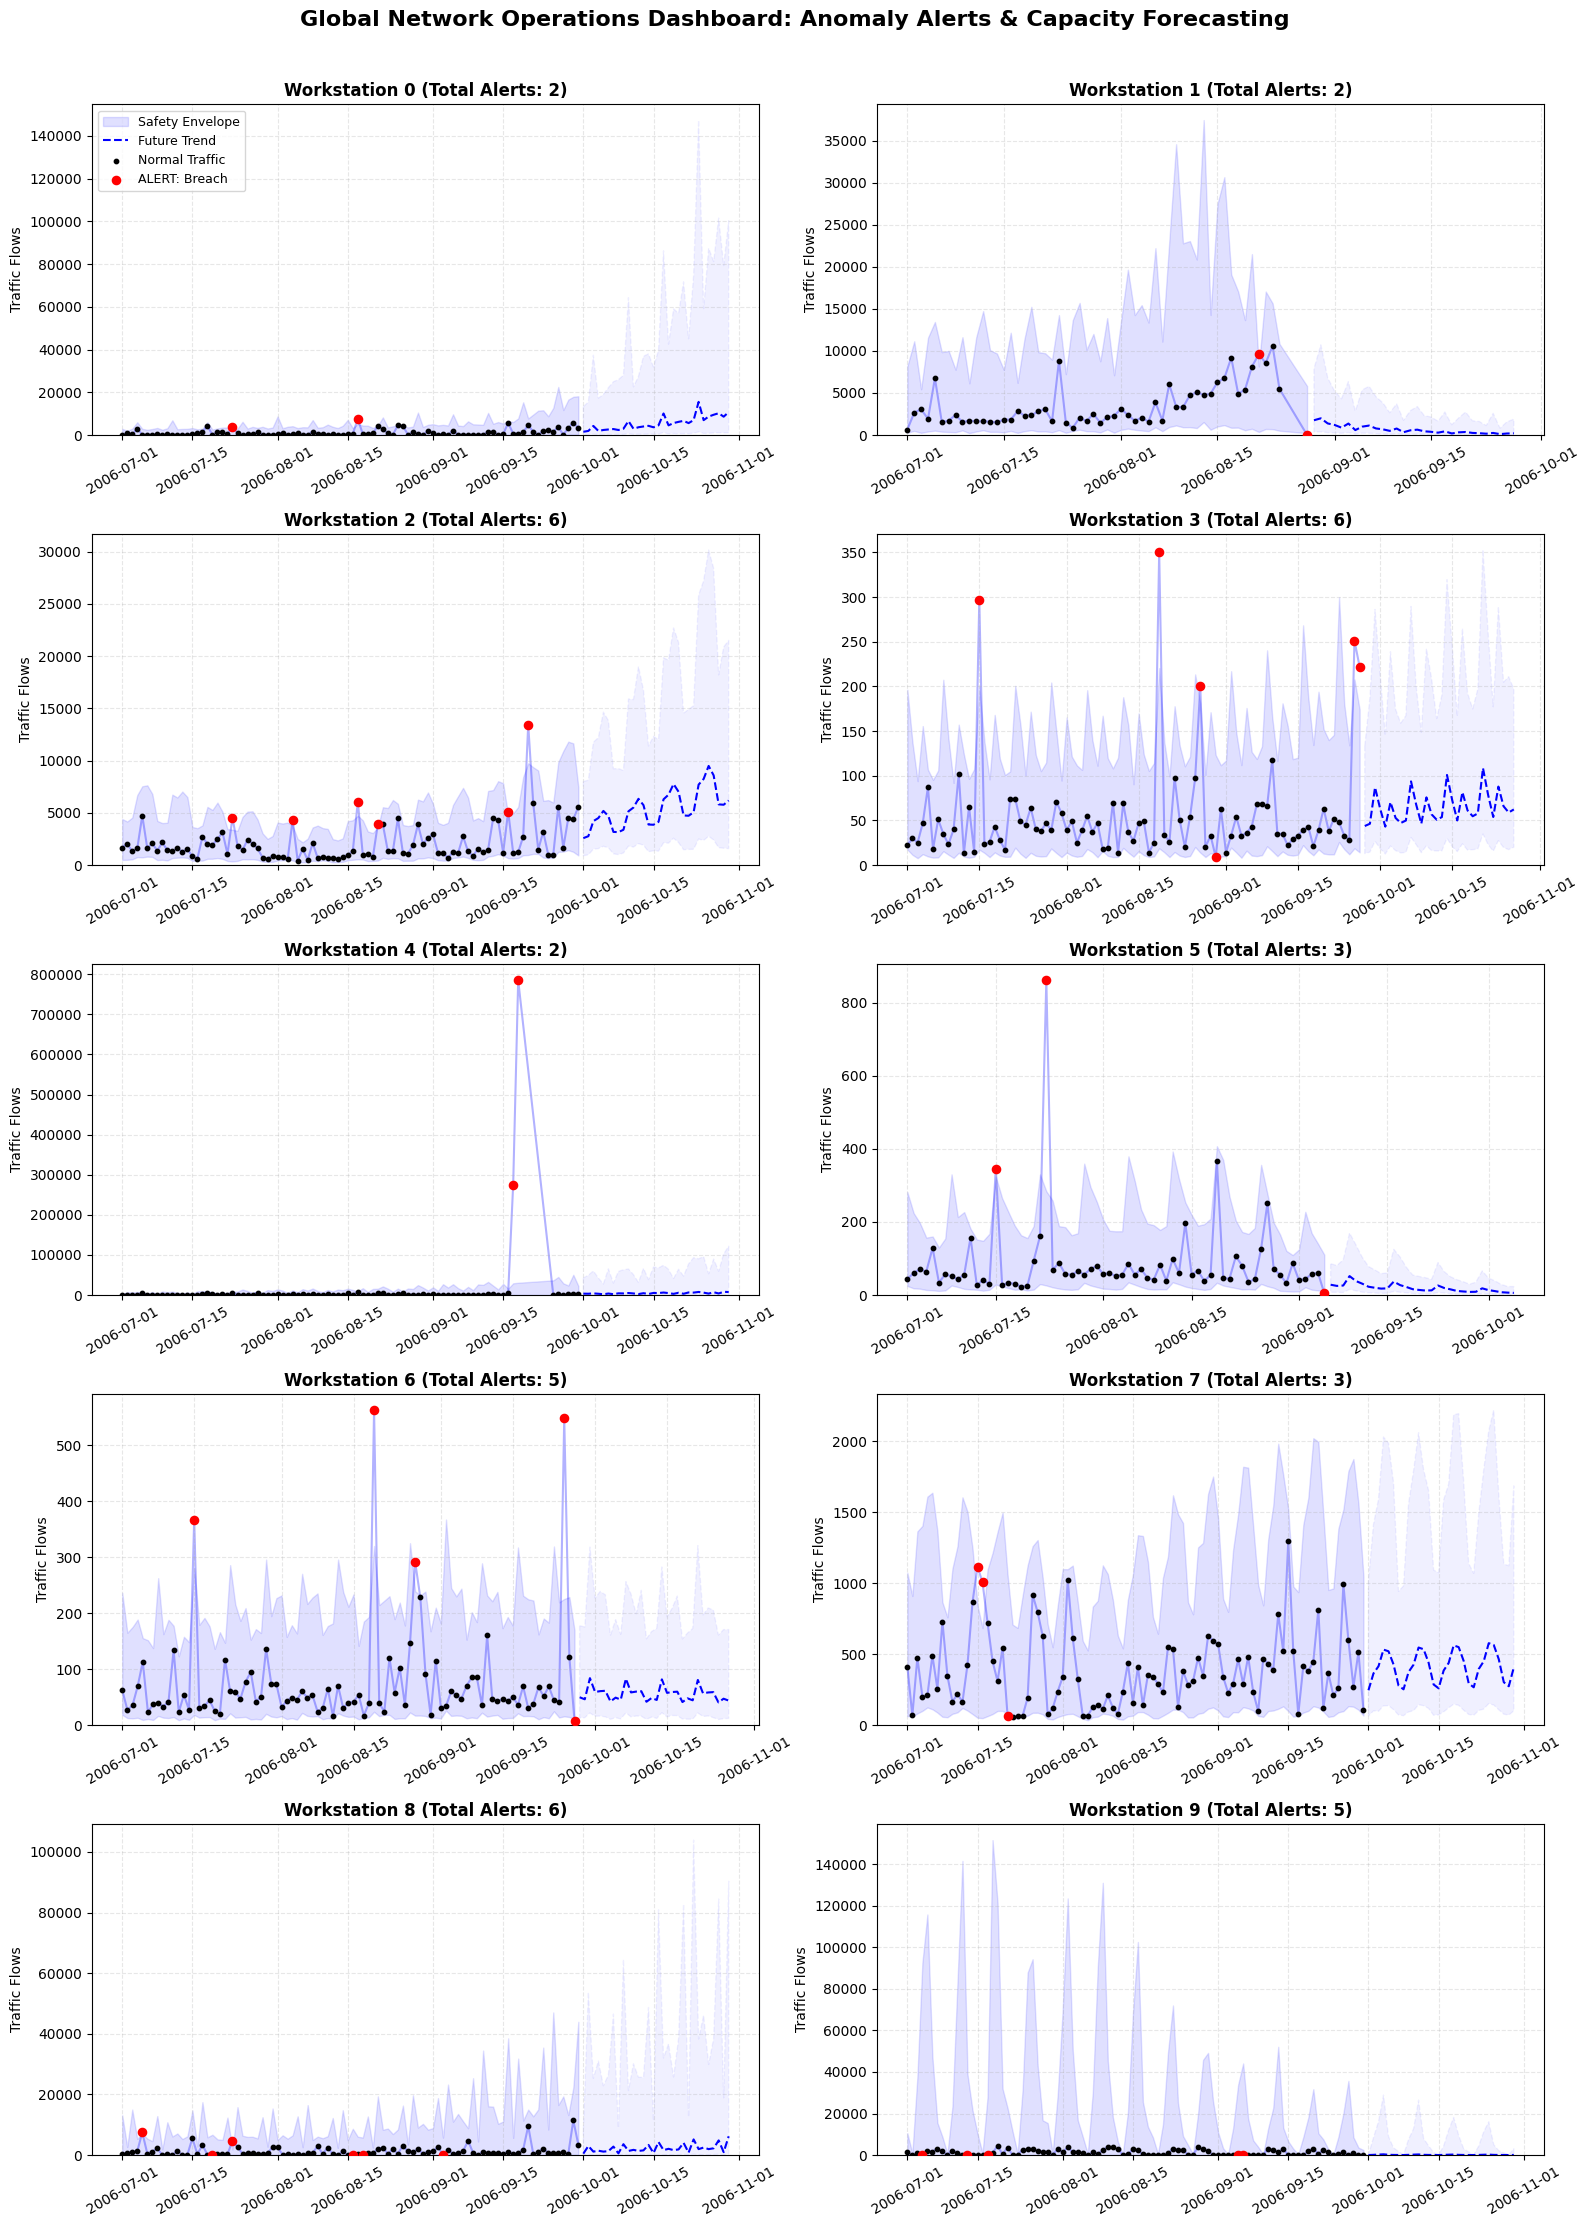

In [ ]:
# Get a sorted list of unique workstations from our processed master database
unique_ws = sorted(master_anomaly_db['l_ipn'].unique())
num_ws = len(unique_ws)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))
axes = axes.flatten()  # Flatten into a 1D array for easy sequential looping

for i, ws in enumerate(unique_ws):
    ax = axes[i]
    
    # Filter out historical results and future forecasts for this specific machine
    ws_hist = master_anomaly_db[master_anomaly_db['l_ipn'] == ws].sort_values('date')
    ws_fut = master_future_forecast_db[master_future_forecast_db['l_ipn'] == ws].sort_values('ds')
    
    # Draw the 95% Safety Envelope across the historical timeline
    ax.fill_between(ws_hist['date'], ws_hist['lower_safety_limit'], ws_hist['upper_safety_limit'], 
                    color='blue', alpha=0.12, label='Safety Envelope')
    
    # Draw the Future Forecast Boundaries across the lookahead timeline
    ax.fill_between(ws_fut['ds'], ws_fut['yhat_lower'], ws_fut['yhat_upper'], 
                    color='blue', alpha=0.06, linestyle='--')
    
    # Plot the Expected Future Trend Line (Dashed)
    ax.plot(ws_fut['ds'], ws_fut['yhat'], color='blue', linewidth=1.5, linestyle='--', label='Future Trend')
    
    # Plot Normal Past Traffic
    normal_data = ws_hist[ws_hist['is_anomaly'] == False]
    ax.plot(ws_hist['date'], ws_hist['f'], color='blue', alpha=0.3, zorder=1) # Connective line
    ax.scatter(normal_data['date'], normal_data['f'], color='black', s=10, label='Normal Traffic', zorder=2)
    
    # Highlight Active Threshold Breaches in RED
    anomaly_data = ws_hist[ws_hist['is_anomaly'] == True]
    ax.scatter(anomaly_data['date'], anomaly_data['f'], color='red', s=35, label='ALERT: Breach', zorder=5)
    

    ax.set_title(f'Workstation {ws} (Total Alerts: {len(anomaly_data)})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Traffic Flows')
    ax.set_ylim(bottom=0)  # Ensure local Y-axis stops perfectly at zero
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
    
    # Place a clean, micro-legend on the very first subplot to keep formatting clean
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

# Clean up layout and remove any unused grid boxes
for j in range(num_ws, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Global Network Operations Dashboard: Anomaly Alerts & Capacity Forecasting', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Conclusion

### Key Findings

- Traffic behavior differs significantly across monitored workstations.
- Multiple workstations exhibited statistically significant traffic spikes and deviations from historical baselines.
- Known investigation periods corresponded with abnormal traffic behavior identified through statistical monitoring.
- Forecasting models successfully established expected traffic baselines for future monitoring.


### Operational Recommendations
- **Automate detection**: The company should ransition away from human-triggered investigations toward automated 7-day rolling statistical limits to flag anomalies the exact day they occur.Detection lag analysis shows 3–7 days between first statistical flag and human awareness; automated alerts eliminate this gap.
- **Peer Group Analysis:** Engineers should cross-examine uninvestigated workstations against each other to identify machines that are flat, but running at a deceptively high baseline volume compared to their peers.
- **Monitor Communication Diversity Alongside Traffic Volume**: Traffic volume alone may not fully explain workstation behavior. Tracking changes in the number of remote networks (ASNs) contacted by a workstation can provide additional insight into potentially suspicious communication patterns.